<a href="https://colab.research.google.com/github/alex-olar-2/tehinva-project/blob/main/olar_alex_tema_b_income_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acest Notebook a fost preluat de la Stefan-Gheorghe PENTIUC precizați sursa, autorul, link-
ul https://classroom.google.com/c/ODQ1ODIxOTcyMzQ4 astfel:

- secventele de cod 50 %
- comentariile 0 %

Acest Notebook a fost generat din GEMINI precizați sursa, autorul, link-
ul https://gemini.google.com/app astfel:

- secventele de cod 20 %
- comentariile 0 %

Conributia personala a constat în:
- adaptarea codului
- studierea documentelor
- comentarii

Valorile procentuale de mai sunt aproximative dar reflectă în esență adevărul.

# 1.   Descrierea problemei




## 1.1. Partea teoretica

Vizualizarea datelor [1] folosind biblioteci si cod .py

## 1.2. Partea practica

Validarea informatiilor fisierului income_evaluation.csv prin 2 metode de invatare:

1.   Regresie
2.   Clasificare



# 2. Procesarea datelor

In [57]:
import kagglehub
import pandas as pd
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

file_path = 'income_evaluation.csv'

column_names = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

target_names = ['<=50K', '>50K']

data_frame = pd.read_csv(file_path, sep=',', names=column_names, header=0)

data_frame_without_income = data_frame.drop(columns='income')

matrix_data_frame_without_income = data_frame_without_income.to_numpy()

income_feature = data_frame['income'].str.strip().map({'<=50K': 1, '>50K': 2})

income_feature_vector = income_feature.to_numpy()

row_number, column_number = matrix_data_frame_without_income.shape

max_income_feature_vector =  max(income_feature_vector)

print("Primele 3 randuri din matricea datelor: \n", matrix_data_frame_without_income[:3])

print("Primele 2 valori din vectorul coloanei income: \n", income_feature_vector[:2])

print("Nr. de linii si de coloane al matricei: \n", matrix_data_frame_without_income.shape)

print("Nr. valori a vectorului de income: \n", income_feature_vector.shape)

print("Valoarea cea mai des intalnita in vecotrul de income: \n", max_income_feature_vector)

Primele 3 randuri din matricea datelor: 
 [[39 ' State-gov' 77516 ' Bachelors' 13 ' Never-married' ' Adm-clerical'
  ' Not-in-family' ' White' ' Male' 2174 0 40 ' United-States']
 [50 ' Self-emp-not-inc' 83311 ' Bachelors' 13 ' Married-civ-spouse'
  ' Exec-managerial' ' Husband' ' White' ' Male' 0 0 13 ' United-States']
 [38 ' Private' 215646 ' HS-grad' 9 ' Divorced' ' Handlers-cleaners'
  ' Not-in-family' ' White' ' Male' 0 0 40 ' United-States']]
Primele 2 valori din vectorul coloanei income: 
 [1 1]
Nr. de linii si de coloane al matricei: 
 (32561, 14)
Nr. valori a vectorului de income: 
 (32561,)
Valoarea cea mai des intalnita in vecotrul de income: 
 2


Sursa: lab_seeds_v3.ipynb [2]

Debug: Gemini [3]

# 3. Analiza Explorativa a Datelor

## 3.1. Vizualizarea datelor 3D

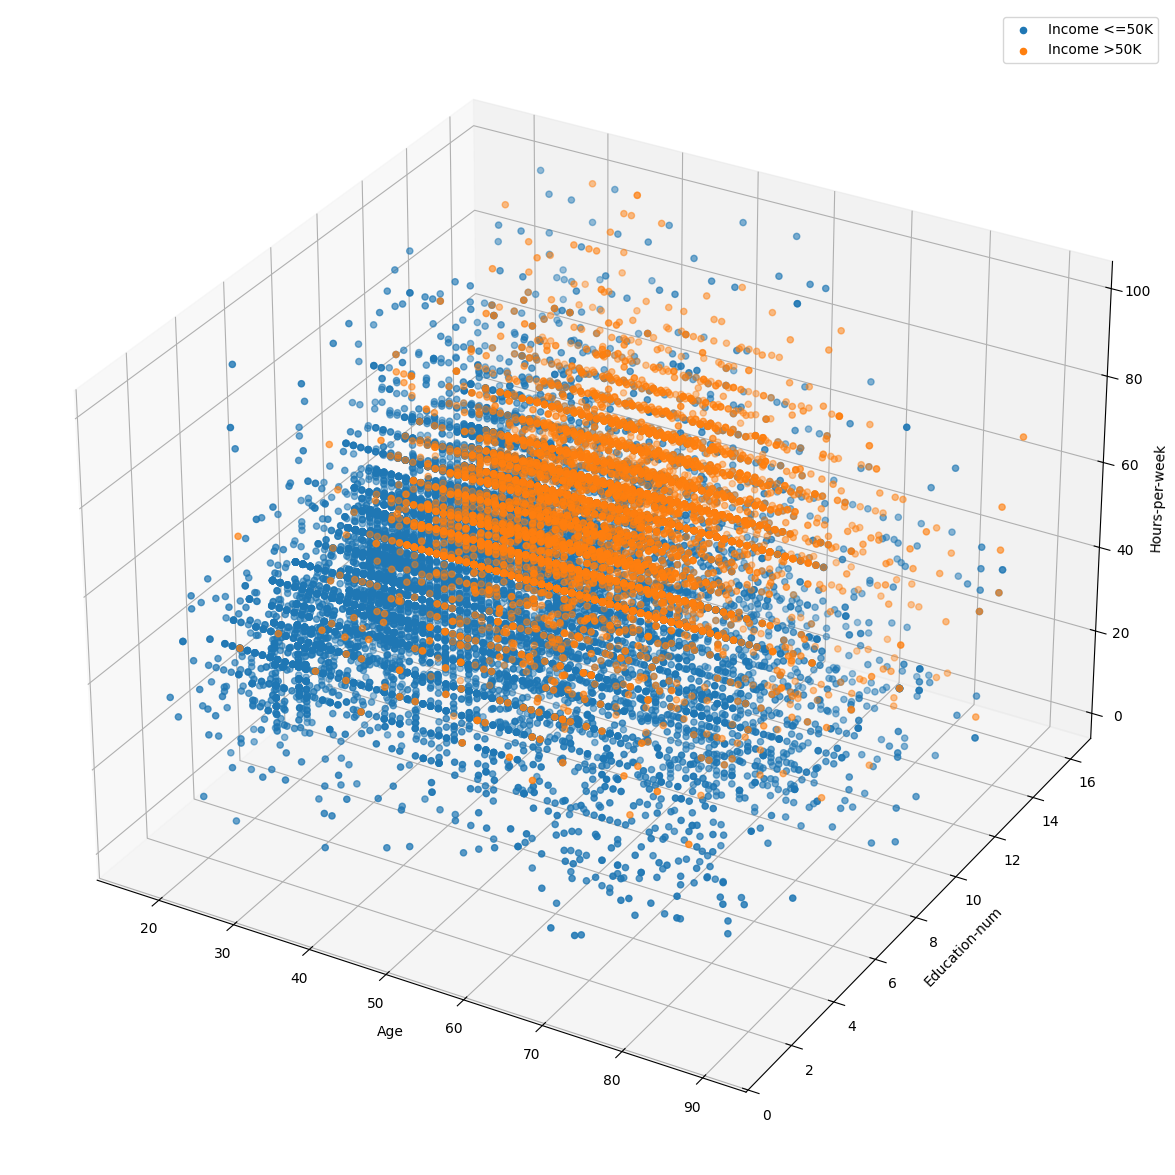

In [68]:
import matplotlib.pyplot as plt

colours = ('r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple')

fig = plt.figure(figsize=(15, 15))

add_subplot = fig.add_subplot(111, projection='3d')

for iclass in range(1, min(max_income_feature_vector + 1, len(colours))):
    add_subplot.scatter(
        matrix_data_frame_without_income[income_feature_vector == iclass, 0].astype(float),
        matrix_data_frame_without_income[income_feature_vector == iclass, 4].astype(float),
        matrix_data_frame_without_income[income_feature_vector == iclass, 12].astype(float),
        label=f'Income {"<=50K" if iclass == 1 else ">50K"}'
    )

add_subplot.set_xlabel('Age')
add_subplot.set_ylabel('Education-num')
add_subplot.set_zlabel('Hours-per-week')
add_subplot.legend()

plt.show()

## 3.2. Vizualizarea datelor 2D

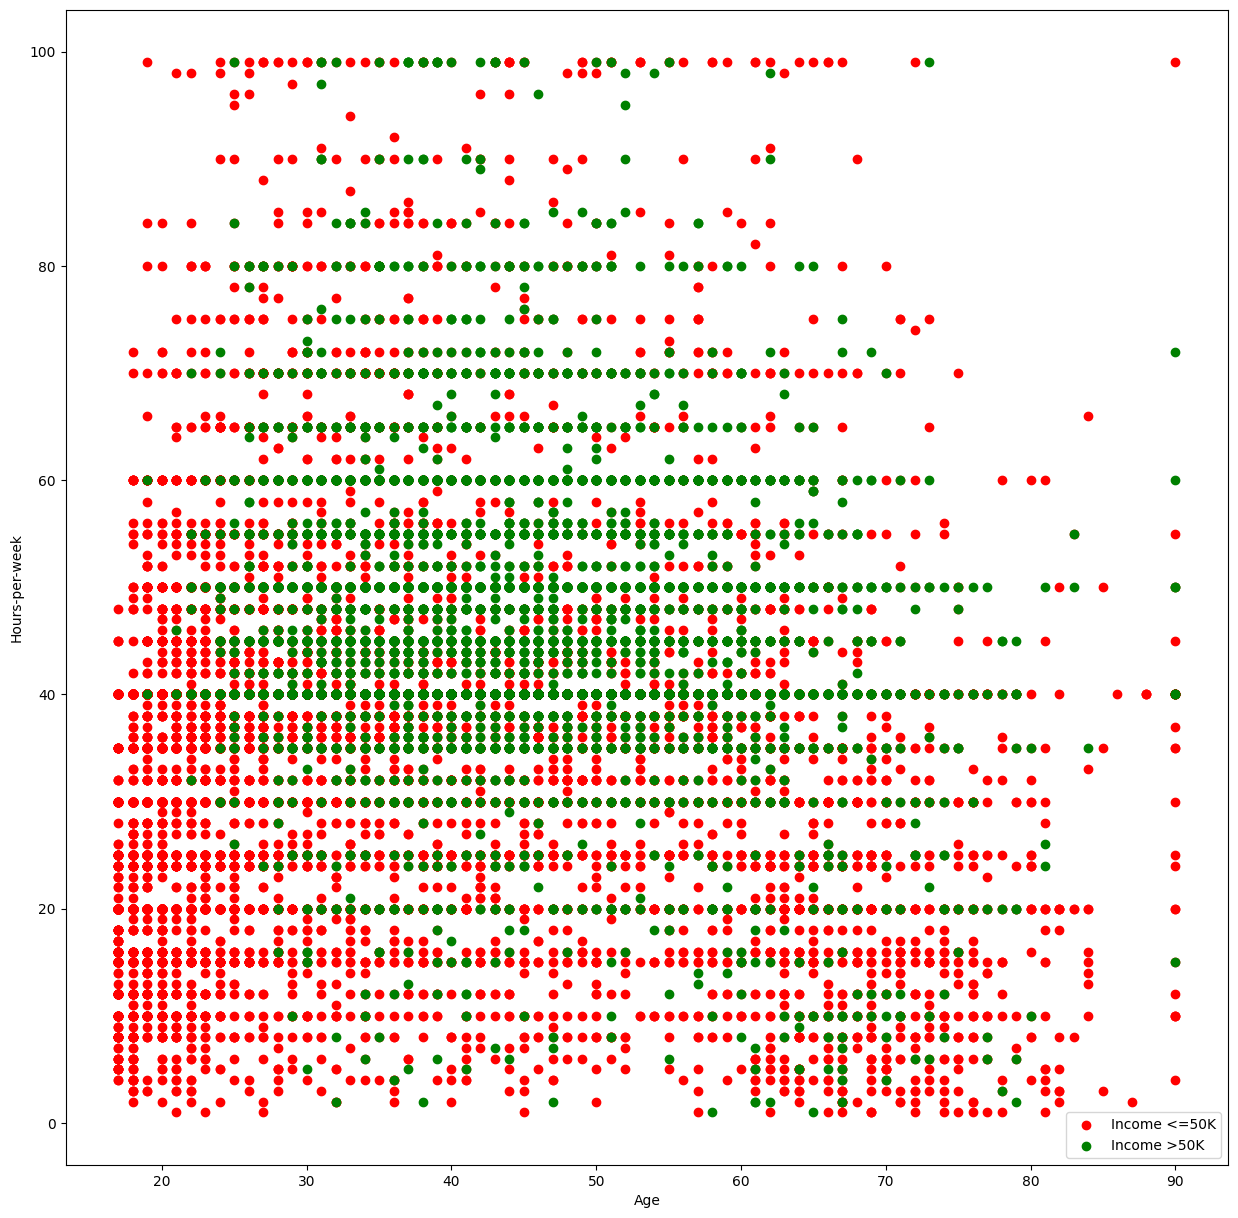

In [67]:
plt.figure(figsize=(15, 15))

for iclass in range(1, min(max_income_feature_vector + 1, len(colours))):
    plt.scatter(
        matrix_data_frame_without_income[income_feature_vector == iclass, 0].astype(float),
        matrix_data_frame_without_income[income_feature_vector == iclass, 12].astype(float),
        c=colours[iclass-1],
        label=f'Income {"<=50K" if iclass == 1 else ">50K"}'
    )

plt.xlabel('Age')
plt.ylabel('Hours-per-week')
plt.legend()

plt.show()

## 3.3 Vizualizare TSNE

Nr. de linii si coloane a matricii in 2d: 
 (100, 2)


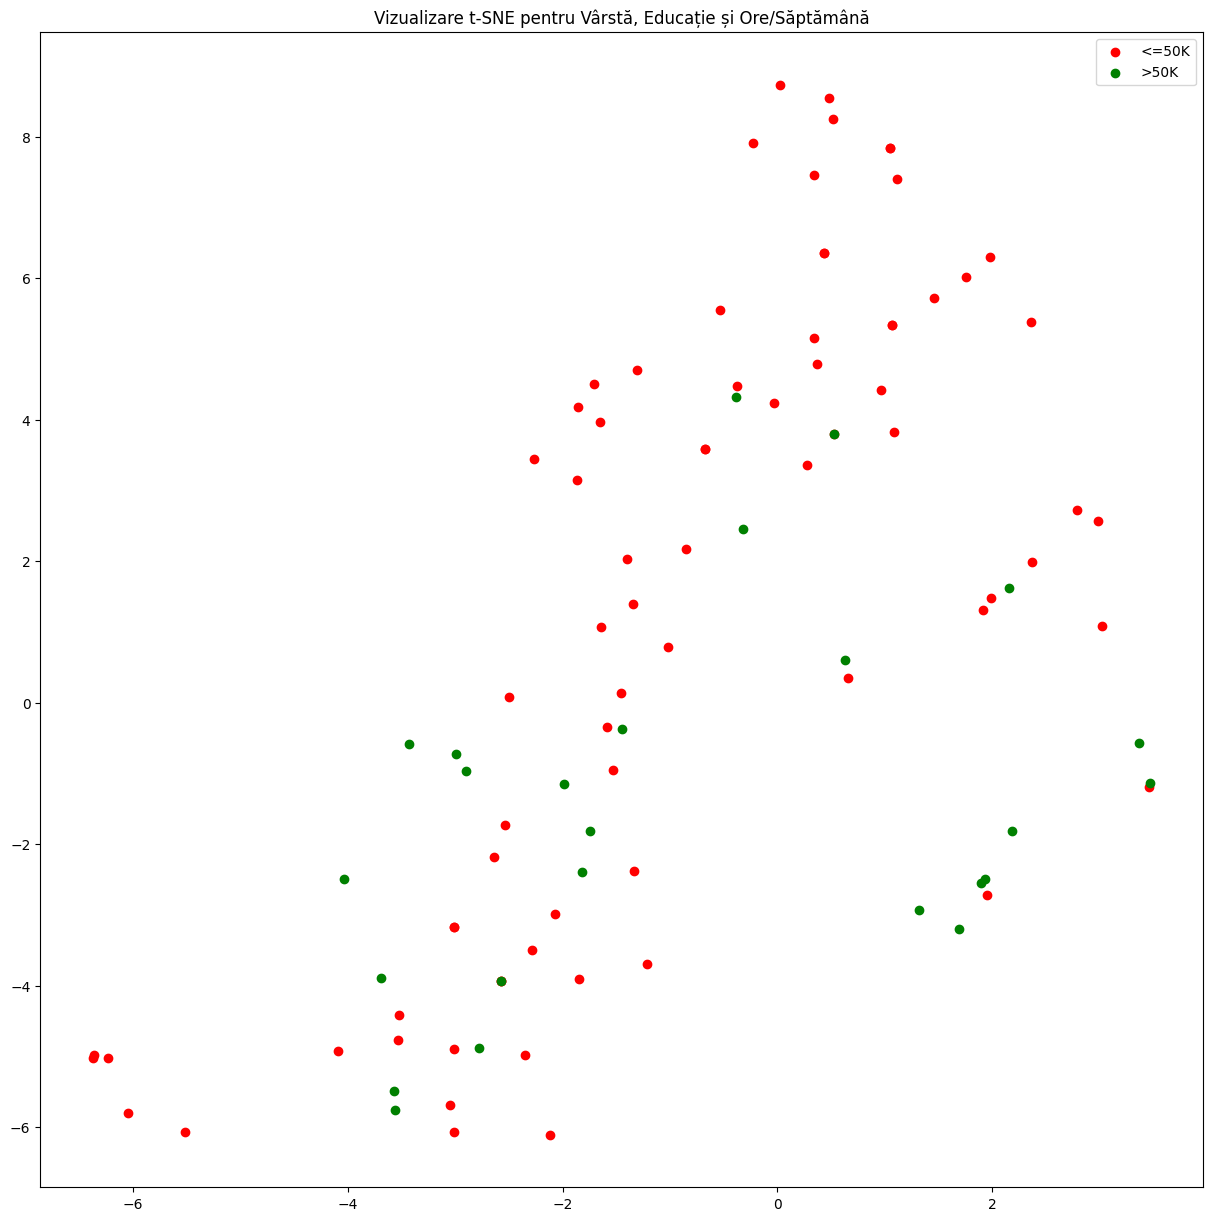

In [92]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

def afisTSNE(matrix_data_frame_without_income, income_feature_vector, n_components = 2):
    tsne = TSNE(n_components, random_state = 0)

    indici_numerici = [0, 4, 12]

    matrix_data_frame_without_income_2d = tsne.fit_transform(
        matrix_data_frame_without_income[:, indici_numerici].astype(float)
    )
    print("Nr. de linii si coloane a matricii in 2d: \n", matrix_data_frame_without_income_2d.shape)

    target_ids = range(1, len(target_names) + 1)

    fig = plt.figure(figsize=(15, 15))
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')

    colors = 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple'

    for i, c, label in zip(target_ids, colors, target_names):
        if n_components==2:
            plt.scatter(
                matrix_data_frame_without_income_2d[income_feature_vector == i, 0].astype(float),
                matrix_data_frame_without_income_2d[income_feature_vector == i, 1].astype(float),
                c=c,
                label=label
            )
        else:
            ax.scatter(
                matrix_data_frame_without_income_2d[income_feature_vector == i, 0].astype(float),
                matrix_data_frame_without_income_2d[income_feature_vector == i, 1].astype(float),
                matrix_data_frame_without_income_2d[income_feature_vector == i, 2].astype(float),
                c=c,
                label=label
            )

    plt.legend()
    plt.title("Vizualizare t-SNE pentru Vârstă, Educație și Ore/Săptămână")
    plt.show()

afisTSNE(matrix_data_frame_without_income[:100], income_feature_vector[:100])

Sursa cod initial: lab_seeds_v3.ipynb [2]

Debug: Gemini [3]

# 4. Modelare de invatare automata

## a) Regresie si/sau

## b) Clasificare

# 5. Compararea si validarea modelelor

# 6. Implementarea

# 7. Concluzii

# 8. Referinte

[1]
Lorenzo De Tomasi, "Income classification", https://www.kaggle.com/datasets/lodetomasi1995/income-classification/code

[3] Google, "Gemini", https://gemini.google.com/app

# 9. Anexe

[2] Stefan-Gheorghe PENTIUC, "Lucrarea de laborator nr. 5", https://drive.google.com/file/d/1wH6EDkZWXNpJukRhQFxcvK2j1NdG7e4k/view